In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time

from brian2 import (
    NeuronGroup, Synapses, SpikeMonitor, Network,
    ms, mV, defaultclock, prefs
)
from sklearn.linear_model import Ridge, Lasso

import logging
from brian2 import BrianLogger
BrianLogger.suppress_name('resolution_conflict')

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..',)))
from lib.utils.reservoirpy import (
    fit_scaler, transform_array, inverse_transform_array
)

prefs.codegen.target = "numpy"   # switch to "cython" for ~5× speedup after debugging
np.random.seed(42)

In [2]:
# ==========================================================
# ENCODER
# ==========================================================
def encode(x_scalar, encoding, input_gain_mV):
    if encoding == "direct":
        return np.full(N_input_neurons_fix, float(x_scalar)) * input_gain_mV * mV
    else:  # population
        bumps = np.exp(-((mu - float(x_scalar)) ** 2) / (2 * sigma_enc_fix ** 2))
        return bumps * input_gain_mV * mV


# ==========================================================
# LIQUID BUILDER
# ==========================================================
def build_liquid(N_liquid, tau_mem, w_exc, w_inh, w_input, rng_seed):
    """Construct a fresh Brian2 Network for one trial."""
    np.random.seed(rng_seed)

    eqs = '''
    dV/dt = ((V_rest - V) + I_syn + I_input) / tau_mem : volt (unless refractory)
    dI_syn/dt = -I_syn / tau_syn : volt
    I_input : volt
    '''
    namespace = dict(
        V_rest=V_rest_fix, tau_mem=tau_mem, tau_syn=tau_syn_fix,
    )

    liquid = NeuronGroup(
        N_liquid, eqs,
        threshold='V > V_thresh', reset='V = V_reset',
        refractory=refractory_fix, method='euler',
        namespace={**namespace, 'V_thresh': V_thresh_fix, 'V_reset': V_reset_fix},
    )
    liquid.V = V_rest_fix

    # Excitatory & inhibitory recurrent synapses
    S_exc = Synapses(liquid, liquid, on_pre='I_syn_post += w_exc',
                     namespace={'w_exc': w_exc})
    S_exc.connect(condition='i != j', p=conn_prob_fix)

    S_inh = Synapses(liquid, liquid, on_pre='I_syn_post += w_inh',
                     namespace={'w_inh': w_inh})
    S_inh.connect(condition='i != j', p=conn_prob_fix)

    # Input layer
    input_eqs = '''
    dV/dt = (V_rest - V + I_drive) / tau_mem : volt (unless refractory)
    I_drive : volt
    '''
    input_layer = NeuronGroup(
        N_input_neurons_fix, input_eqs,
        threshold='V > V_thresh', reset='V = V_reset',
        refractory=refractory_fix, method='euler',
        namespace={'V_rest': V_rest_fix, 'V_thresh': V_thresh_fix,
                   'V_reset': V_reset_fix, 'tau_mem': tau_mem},
    )
    input_layer.V = V_rest_fix

    S_in = Synapses(input_layer, liquid, on_pre='I_syn_post += w_input',
                    namespace={'w_input': w_input})
    S_in.connect(p=input_conn_prob_fix)

    spike_mon = SpikeMonitor(liquid)
    net = Network(liquid, input_layer, S_exc, S_inh, S_in, spike_mon)
    net.store('initial')

    return net, input_layer, spike_mon


# ==========================================================
# STATE COLLECTION
# ==========================================================
def collect_states(net, input_layer, spike_mon, N_liquid,
                   step_duration, tau_mem, input_sequence,
                   encoding, input_gain_mV, continue_from=None):
    """Run the liquid; return (states, filt_state_final)."""
    T = len(input_sequence)
    states = np.zeros((T, N_liquid))
    filt = np.zeros(N_liquid) if continue_from is None else continue_from.copy()
    decay = np.exp(-float(step_duration / tau_syn_fix))

    for t in range(T):
        input_layer.I_drive = encode(input_sequence[t, 0], encoding, input_gain_mV)
        spikes_before = len(spike_mon.t)
        net.run(step_duration)
        new_idx = np.array(spike_mon.i[spikes_before:])
        counts = np.bincount(new_idx, minlength=N_liquid).astype(float)
        filt = filt * decay + counts
        states[t] = filt

    return states, filt


# ==========================================================
# EVALUATION FUNCTION
# ==========================================================
def evaluate_lsm(
    normalization, train_warmup, test_warmup,
    N_liquid, tau_mem_ms, encoding,
    step_duration_ms, w_exc_mV, inh_ratio,
    input_gain_mV, w_input_mV, regression,
    rng_seed=42,
):
    try:
        from brian2 import start_scope
        start_scope()
        
        if test_warmup >= test_len:
            return np.inf

        tau_mem       = tau_mem_ms * ms
        step_duration = step_duration_ms * ms
        w_exc         = w_exc_mV * mV
        w_inh         = -inh_ratio * w_exc_mV * mV
        w_input       = w_input_mV * mV

        # Scale data
        scaler  = fit_scaler(X_train_raw, method=normalization)
        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test  = transform_array(X_test_raw, scaler)
        Y_test  = transform_array(Y_test_raw, scaler)

        pred_len = test_len - test_warmup
        Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len, 0]

        if train_warmup >= len(X_train):
            return np.inf

        # Build liquid
        net, input_layer, spike_mon = build_liquid(
            N_liquid, tau_mem, w_exc, w_inh, w_input, rng_seed
        )

        # --- Training: collect states ---
        net.restore('initial')
        S_train, _ = collect_states(
            net, input_layer, spike_mon, N_liquid,
            step_duration, tau_mem, X_train, encoding, input_gain_mV,
        )

        # Health check: if liquid is silent or saturated, bail early
        mean_rate = S_train.mean()
        if mean_rate < 1e-3 or mean_rate > 1e4 or not np.isfinite(mean_rate):
            return np.inf

        S_train_fit = S_train[train_warmup:]
        Y_train_fit = Y_train[train_warmup:, 0]

        if regression_model == "ridge":
            readout = Ridge(alpha=regression)
        else:
            readout = Lasso(alpha=regression, max_iter=10000)
        readout.fit(S_train_fit, Y_train_fit)

        # --- Sync: drive with true test inputs ---
        net.restore('initial')
        _, filt = collect_states(
            net, input_layer, spike_mon, N_liquid,
            step_duration, tau_mem, X_test[:test_warmup],
            encoding, input_gain_mV,
        )

        # --- Closed-loop rollout (continue same simulation) ---
        Y_pred_scaled = np.zeros(pred_len)
        decay = np.exp(-float(step_duration / tau_syn_fix))
        current_input = X_test[test_warmup, 0]

        for k in range(pred_len):
            input_layer.I_drive = encode(current_input, encoding, input_gain_mV)
            spikes_before = len(spike_mon.t)
            net.run(step_duration)
            new_idx = np.array(spike_mon.i[spikes_before:])
            counts = np.bincount(new_idx, minlength=N_liquid).astype(float)
            filt = filt * decay + counts

            pred = readout.predict(filt.reshape(1, -1))[0]
            if not np.isfinite(pred) or abs(pred) > 1e6:
                return np.inf
            Y_pred_scaled[k] = pred
            current_input = pred

        rmse  = np.sqrt(np.mean((Y_true_scaled - Y_pred_scaled) ** 2))
        denom = np.std(Y_true_scaled)
        if denom == 0:
            return np.inf
        return rmse / denom

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf

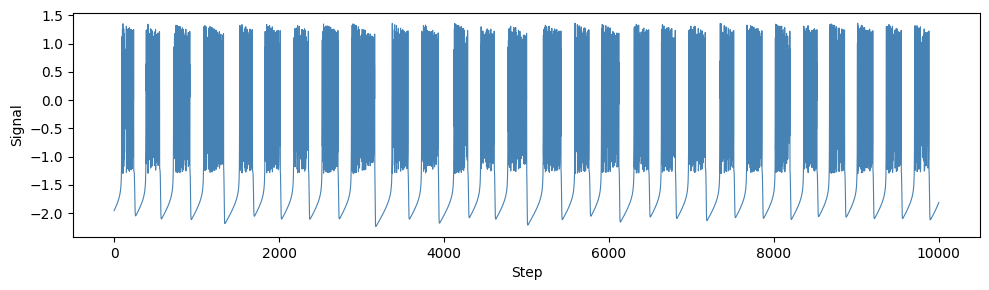

In [3]:
# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[:, 0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset, color='steelblue', linewidth=0.8)
ax.set_xlabel('Step'); ax.set_ylabel('Signal')
plt.tight_layout(); plt.show()

In [4]:
# ==========================================================
# DATA PREPARATION
# ==========================================================
data = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]


# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len        = 4000
test_start       = 4000
test_len         = 1000

regression_model = "ridge"   # "ridge" or "lasso"
seed             = 42

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw  = X_raw[test_start:test_start + test_len]
Y_test_raw  = Y_raw[test_start:test_start + test_len]


# ==========================================================
# FIXED LSM STRUCTURAL PARAMETERS (Tier 3)
# ==========================================================
# These are held constant across all trials. See discussion above for why.
tau_syn_fix            = 5 * ms
V_rest_fix             = -65 * mV
V_reset_fix            = -65 * mV
V_thresh_fix           = -50 * mV
refractory_fix         = 2 * ms
exc_frac_fix           = 0.8
conn_prob_fix          = 0.1
input_conn_prob_fix    = 0.3
N_input_neurons_fix    = 50
sigma_enc_fix          = 0.2
dt_sim                 = 1 * ms
defaultclock.dt        = dt_sim

# Encoder preferred values (population coding)
mu = np.linspace(-1.0, 1.0, N_input_neurons_fix)

Total combinations to evaluate: 72
[5/72]  elapsed: 1441s  ETA: 19304s  current best NRMSE: 1.284300
[10/72]  elapsed: 2912s  ETA: 18053s  current best NRMSE: 1.284300
[15/72]  elapsed: 4394s  ETA: 16698s  current best NRMSE: 1.284300
[20/72]  elapsed: 5897s  ETA: 15331s  current best NRMSE: 1.284300
[25/72]  elapsed: 7407s  ETA: 13925s  current best NRMSE: 1.284300
[30/72]  elapsed: 8933s  ETA: 12506s  current best NRMSE: 1.284300
[35/72]  elapsed: 10471s  ETA: 11070s  current best NRMSE: 1.284300
[40/72]  elapsed: 12041s  ETA: 9633s  current best NRMSE: 1.284300
[45/72]  elapsed: 13624s  ETA: 8175s  current best NRMSE: 1.284300
[50/72]  elapsed: 15223s  ETA: 6698s  current best NRMSE: 1.185028
[55/72]  elapsed: 16836s  ETA: 5204s  current best NRMSE: 1.117002
[60/72]  elapsed: 18438s  ETA: 3688s  current best NRMSE: 1.117002
[65/72]  elapsed: 20023s  ETA: 2156s  current best NRMSE: 1.117002
[70/72]  elapsed: 21626s  ETA: 618s  current best NRMSE: 1.117002
[72/72]  elapsed: 22270s  ET

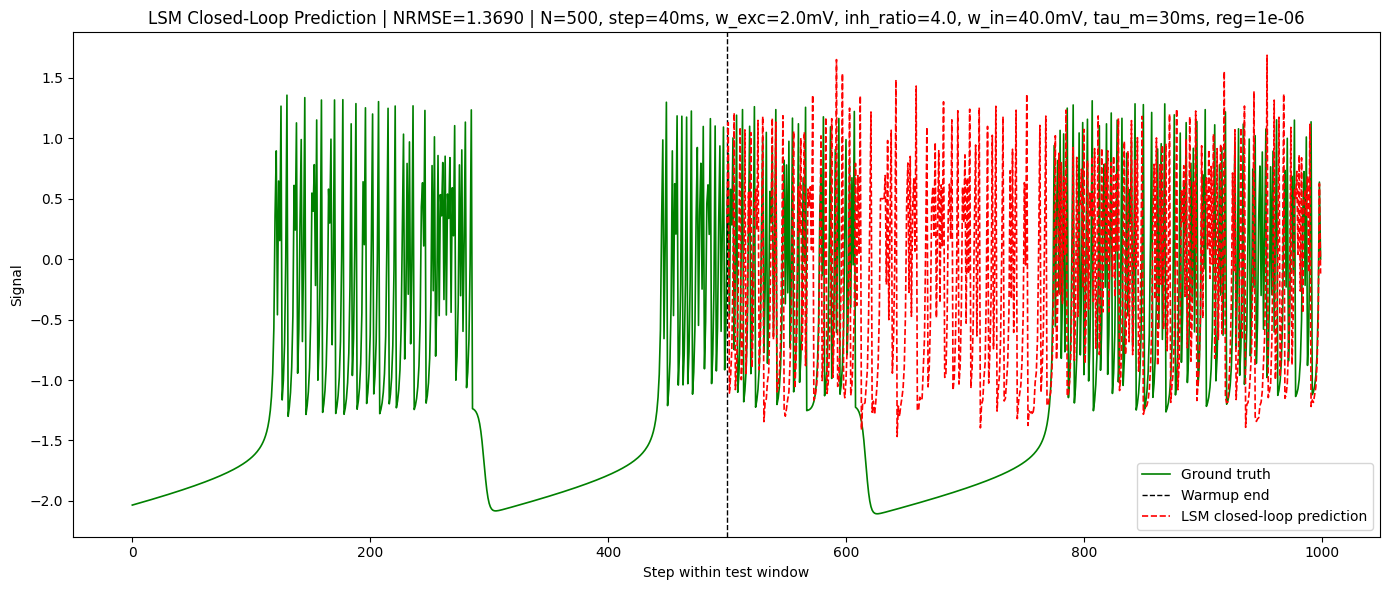

In [5]:
# ==========================================================
# PARAMETER GRID
# ==========================================================
# Tier 1 swept fully; Tier 2 swept coarsely; Tier 3 fixed above.
param_grid = {
    "normalization":     ["minmax11"],
    "train_warmup":      [200],
    "test_warmup":       [500],
    "N_liquid":          [500],
    "tau_mem_ms":        [30],
    "encoding":          ["population"],

    "step_duration_ms":  [25, 40],
    "w_exc_mV":          [1.0, 2.0, 3.0],
    "inh_ratio":         [3.0, 4.0, 5.0],
    "input_gain_mV":     [30.0, 45.0],
    "w_input_mV":        [15.0, 40.0],
    "regression":        [1e-6],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))
print(f"Total combinations to evaluate: {len(combos)}")


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results = []
best_nrmse  = np.inf
best_params = None
t_start     = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse  = evaluate_lsm(**params, rng_seed=seed)
    results.append({**params, "nrmse": nrmse})

    if nrmse < best_nrmse:
        best_nrmse  = nrmse
        best_params = params.copy()

    if (i + 1) % 5 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        eta     = elapsed / (i + 1) * (len(combos) - (i + 1))
        print(
            f"[{i+1}/{len(combos)}]  "
            f"elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s  "
            f"current best NRMSE: {best_nrmse:.6f}"
        )

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("LSM GRID SEARCH COMPLETE")
print(f"Train interval      : [0 : {train_len}]")
print(f"Test interval       : [{test_start} : {test_start + test_len}]")
print(f"Total time          : {total_time:.1f}s ({total_time/len(combos):.2f}s per trial)")
print(f"Regression model    : {regression_model}")
print(f"Best NRMSE          : {best_nrmse:.6f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:24s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["nrmse"])

print("\nTop 10 configurations:")
print(
    f"{'Rank':>4}  {'N':>5}  {'step':>5}  {'w_exc':>6}  {'inh_r':>5}  "
    f"{'w_in':>5}  {'tau_m':>5}  {'reg':>8}  {'NRMSE':>10}"
)
print("-" * 80)
for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['N_liquid']):5d}  "
        f"{r['step_duration_ms']:5.1f}  "
        f"{r['w_exc_mV']:6.2f}  "
        f"{r['inh_ratio']:5.1f}  "
        f"{r['w_input_mV']:5.2f}  "
        f"{r['tau_mem_ms']:5.1f}  "
        f"{r['regression']:8.1e}  "
        f"{r['nrmse']:10.6f}"
    )


# ==========================================================
# REBUILD BEST MODEL & PLOT
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])
X_train_b   = transform_array(X_train_raw, best_scaler)
Y_train_b   = transform_array(Y_train_raw, best_scaler)
X_test_b    = transform_array(X_test_raw,  best_scaler)
Y_test_b    = transform_array(Y_test_raw,  best_scaler)

bp            = best_params
tau_mem_b     = bp["tau_mem_ms"] * ms
step_dur_b    = bp["step_duration_ms"] * ms
w_exc_b       = bp["w_exc_mV"] * mV
w_inh_b       = -bp["inh_ratio"] * bp["w_exc_mV"] * mV
w_input_b     = bp["w_input_mV"] * mV
input_gain_b  = bp["w_input_mV"]

net, input_layer, spike_mon = build_liquid(
    bp["N_liquid"], tau_mem_b, w_exc_b, w_inh_b, w_input_b, seed
)

# Train
net.restore('initial')
S_train, _ = collect_states(
    net, input_layer, spike_mon, bp["N_liquid"],
    step_dur_b, tau_mem_b, X_train_b, bp["encoding"], input_gain_b,
)
S_train_fit = S_train[bp["train_warmup"]:]
Y_train_fit = Y_train_b[bp["train_warmup"]:, 0]

if regression_model == "ridge":
    readout = Ridge(alpha=bp["regression"])
else:
    readout = Lasso(alpha=bp["regression"], max_iter=10000)
readout.fit(S_train_fit, Y_train_fit)

# Sync + closed-loop
net.restore('initial')
_, filt = collect_states(
    net, input_layer, spike_mon, bp["N_liquid"],
    step_dur_b, tau_mem_b, X_test_b[:bp["test_warmup"]],
    bp["encoding"], input_gain_b,
)

pred_len = test_len - bp["test_warmup"]
Y_pred_scaled = np.zeros(pred_len)
decay = np.exp(-float(step_dur_b / tau_syn_fix))
current_input = X_test_b[bp["test_warmup"], 0]

for k in range(pred_len):
    input_layer.I_drive = encode(current_input, bp["encoding"], input_gain_b)
    spikes_before = len(spike_mon.t)
    net.run(step_dur_b)
    new_idx = np.array(spike_mon.i[spikes_before:])
    counts  = np.bincount(new_idx, minlength=bp["N_liquid"]).astype(float)
    filt    = filt * decay + counts

    pred = readout.predict(filt.reshape(1, -1))[0]
    Y_pred_scaled[k] = pred
    current_input = pred

Y_pred_b = inverse_transform_array(Y_pred_scaled.reshape(-1, 1), best_scaler).ravel()
Y_true_b = inverse_transform_array(
    Y_test_b[bp["test_warmup"]:bp["test_warmup"] + pred_len], best_scaler
).ravel()

mse   = np.mean((Y_true_b - Y_pred_b) ** 2)
rmse  = np.sqrt(mse)
nrmse = rmse / np.std(Y_true_b)

print("\nFinal best-model metrics in original scale:")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse:.10f}")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test_raw[:, 0], c="green",
        label="Ground truth", linewidth=1.2)
ax.axvline(bp["test_warmup"], linestyle="--", c="k", linewidth=1.0,
           label="Warmup end")
ax.plot(np.arange(bp["test_warmup"], bp["test_warmup"] + pred_len),
        Y_pred_b, linestyle="--", c="red",
        label="LSM closed-loop prediction", linewidth=1.2)
ax.set_title(
    f"LSM Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"N={bp['N_liquid']}, step={bp['step_duration_ms']}ms, "
    f"w_exc={bp['w_exc_mV']}mV, inh_ratio={bp['inh_ratio']}, "
    f"w_in={bp['w_input_mV']}mV, tau_m={bp['tau_mem_ms']}ms, "
    f"reg={bp['regression']:.0e}"
)
ax.set_xlabel("Step within test window"); ax.set_ylabel("Signal")
ax.legend(); plt.tight_layout(); plt.show()

In [10]:
# ==========================================================
# DIAGNOSTIC: run ONE config with verbose output
# ==========================================================
test_params = {
    "normalization":     "minmax11",
    "train_warmup":      200,
    "test_warmup":       500,
    "N_liquid":          500,
    "tau_mem_ms":        30,
    "encoding":          "population",
    "step_duration_ms":  25,
    "w_exc_mV":          2.0,
    "inh_ratio":         4.0,
    "input_gain_mV":     40.0,
    "w_input_mV":        20.0,
    "regression":        1e-5,
}

from brian2 import SpikeMonitor, start_scope

def evaluate_lsm_verbose(**params):
    try:
        # Clean slate — removes orphaned objects from prior cells/trials
        start_scope()

        tau_mem       = params["tau_mem_ms"] * ms
        step_duration = params["step_duration_ms"] * ms
        w_exc         = params["w_exc_mV"] * mV
        w_inh         = -params["inh_ratio"] * params["w_exc_mV"] * mV
        w_input       = params["w_input_mV"] * mV
        input_gain_mV = params["input_gain_mV"]

        scaler  = fit_scaler(X_train_raw, method=params["normalization"])
        X_train = transform_array(X_train_raw, scaler)
        print(f"[OK] scaling done. X_train range: "
              f"[{X_train.min():.3f}, {X_train.max():.3f}]")

        net, input_layer, spike_mon = build_liquid(
            params["N_liquid"], tau_mem, w_exc, w_inh, w_input, 42
        )
        print(f"[OK] liquid built.")

        # Add input-layer monitor BEFORE running (and don't touch 'initial').
        input_spike_mon = SpikeMonitor(input_layer)
        net.add(input_spike_mon)

        # Brian2 subtlety: 'initial' snapshot was created inside build_liquid
        # before input_spike_mon existed. Don't call restore() here — the
        # network is already at t=0 with fresh membrane potentials because
        # build_liquid just finished constructing it.

        S_train, _ = collect_states(
            net, input_layer, spike_mon, params["N_liquid"],
            step_duration, tau_mem, X_train[:500],
            params["encoding"], input_gain_mV,
        )
        print(f"[OK] states collected.")

        # --- INPUT LAYER DIAGNOSTICS ---
        n_input_spikes     = len(input_spike_mon.t)
        input_neurons_fired = len(np.unique(input_spike_mon.i))
        total_sim_time_s   = 500 * float(step_duration)
        input_rate_hz      = n_input_spikes / (N_input_neurons_fix * total_sim_time_s)
        print(f"--- INPUT LAYER ---")
        print(f"     total input spikes           : {n_input_spikes}")
        print(f"     input neurons that fired     : "
              f"{input_neurons_fired}/{N_input_neurons_fix}")
        print(f"     mean input firing rate (Hz)  : {input_rate_hz:.2f}")

        # --- LIQUID DIAGNOSTICS ---
        print(f"--- LIQUID ---")
        print(f"     mean spike count per neuron per step : {S_train.mean():.4f}")
        print(f"     max spike count                      : {S_train.max():.4f}")
        print(f"     fraction of neurons that ever fired  : "
              f"{(S_train.sum(axis=0) > 0).mean():.2%}")
        liquid_rate_hz = S_train.sum() / (params["N_liquid"] * total_sim_time_s)
        print(f"     mean liquid firing rate (Hz)         : {liquid_rate_hz:.2f}")
        print(f"     state matrix shape                   : {S_train.shape}")

        # --- VERDICT ---
        mean_count = S_train.mean()
        if mean_count < 1e-3:
            print(f"[FAIL] liquid silent")
            if n_input_spikes == 0:
                print("       -> input layer silent too. RAISE input_gain_mV.")
            else:
                print("       -> input fires but liquid doesn't. "
                      "RAISE w_input_mV or w_exc_mV.")
        elif liquid_rate_hz > 100:
            print(f"[FAIL] liquid saturated ({liquid_rate_hz:.0f} Hz)")
            print("       -> LOWER w_exc_mV or RAISE inh_ratio.")
        elif liquid_rate_hz < 2:
            print(f"[WARN] liquid alive but sparse ({liquid_rate_hz:.1f} Hz)")
            print("       -> usable, but try raising w_exc_mV a bit.")
        elif liquid_rate_hz > 50:
            print(f"[WARN] liquid hyperactive ({liquid_rate_hz:.1f} Hz)")
            print("       -> ease w_exc_mV down or inh_ratio up.")
        else:
            print(f"[PASS] liquid in healthy range ({liquid_rate_hz:.1f} Hz)")

    except Exception as e:
        import traceback
        traceback.print_exc()

evaluate_lsm_verbose(**test_params)
evaluate_lsm_verbose(**test_params)

[OK] scaling done. X_train range: [-1.000, 1.000]
[OK] liquid built.
[OK] states collected.
--- INPUT LAYER ---
     total input spikes           : 6751
     input neurons that fired     : 50/50
     mean input firing rate (Hz)  : 10.80
--- LIQUID ---
     mean spike count per neuron per step : 0.1351
     max spike count                      : 2.0135
     fraction of neurons that ever fired  : 86.40%
     mean liquid firing rate (Hz)         : 5.40
     state matrix shape                   : (500, 500)
[PASS] liquid in healthy range (5.4 Hz)
[OK] scaling done. X_train range: [-1.000, 1.000]
[OK] liquid built.
[OK] states collected.
--- INPUT LAYER ---
     total input spikes           : 6751
     input neurons that fired     : 50/50
     mean input firing rate (Hz)  : 10.80
--- LIQUID ---
     mean spike count per neuron per step : 0.1351
     max spike count                      : 2.0135
     fraction of neurons that ever fired  : 86.40%
     mean liquid firing rate (Hz)         : 5.